# Task 2 — Proposed Model: ResNet50 + CBAM Attention

**Group: Group03** | **Dataset: PRBD (Processed Rice Bangladesh Dataset)** | **Track: 3 — CNN + Attention**

This notebook builds our attention-augmented model and evaluates it with the **exact same protocol, split, and metric set** as `task2_baselines.ipynb`, so the comparison against the 4 baselines is fair.

**Design rationale — why the backbone is ResNet50, not a from-scratch CNN:** an earlier version of this notebook used a small custom 4-block CNN + CBAM trained from scratch. It beat the from-scratch Simple CNN baseline (Macro-F1 0.899 vs 0.890 — attention helped), but could not beat the pretrained backbones (ResNet50 0.9625, MobileNetV2 0.9622, EfficientNet-B0 0.9524). That comparison was confounded — a small from-scratch network vs. a network pretrained on 1.4M ImageNet images — so the ImageNet pretraining gap dominated any gain attention could provide.

**This version isolates the attention effect properly**, the way CBAM is used in the literature (Woo et al., 2018 build CBAM into ResNet/MobileNet backbones, not tiny from-scratch nets): we take **ResNet50 — the strongest baseline (Macro-F1 0.9625)** — and insert CBAM modules after every residual stage, fine-tuning under the **identical fine-tuning budget as the ResNet50 baseline** (same frozen layers, same unfrozen `layer4`, same learning rate, same everything else). The only difference between "ResNet50 baseline" and "ResNet50 + CBAM proposed model" is the presence of attention — a clean, apples-to-apples test of whether attention helps *on top of* the strongest existing backbone, rather than a test of attention vs. pretraining.

## 0. Setup (identical libraries/seeds as the baselines notebook)

In [1]:
import os, glob, random, time, json, copy, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrow
import seaborn as sns
import cv2
cv2.setNumThreads(0)  # avoid OpenCV internal threading deadlocking with DataLoader workers
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix,
                              roc_curve, auc, precision_recall_curve)
from sklearn.preprocessing import label_binarize

try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
except ImportError:
    os.system("pip install -q albumentations --no-deps")
    import albumentations as A
    from albumentations.pytorch import ToTensorV2

import torchvision
from torchvision import models

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

BASE_PATH = "/kaggle/input/datasets/rejaul1111/prbd-dataset/Original_Images"
WORK_DIR = "/kaggle/working"
SPLIT_DIR = os.path.join(WORK_DIR, "splits")
RESULTS_DIR = os.path.join(WORK_DIR, "results")
MODELS_DIR = os.path.join(WORK_DIR, "models")
for d in [SPLIT_DIR, RESULTS_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

# ---- Where to find task2_baselines.ipynb's committed output ----
# Kaggle mounts an attached notebook's output under /kaggle/input/notebooks/<owner>/<slug>/...
# Update these two if your username or notebook slug differ (run
# os.walk("/kaggle/input/notebooks") in a scratch cell to confirm the exact path if unsure).
BASELINE_NOTEBOOK_SLUG = "cse475-task2-baselines"
BASELINE_NOTEBOOK_OWNER = "rejaul1111"
BASELINE_INPUT_CANDIDATES = [
    f"/kaggle/input/notebooks/{BASELINE_NOTEBOOK_OWNER}/{BASELINE_NOTEBOOK_SLUG}",
    f"/kaggle/input/{BASELINE_NOTEBOOK_SLUG}",
]

def resolve_baseline_file(relative_path):
    # Find a file produced by task2_baselines.ipynb. Checks this session's own
    # /kaggle/working first (covers running both notebooks back-to-back in one
    # session), then falls back to the attached input dataset. Returns None if
    # not found anywhere.
    own_path = os.path.join(WORK_DIR, relative_path)
    if os.path.exists(own_path):
        return own_path
    for root in BASELINE_INPUT_CANDIDATES:
        candidate = os.path.join(root, relative_path)
        if os.path.exists(candidate):
            return candidate
    return None

CLASSES = sorted(os.listdir(BASE_PATH))
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}
print(f"Found {NUM_CLASSES} classes:", CLASSES)

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50
PATIENCE = 6


Device: cuda
GPU: Tesla T4
Found 10 classes: ['Aush', 'BR-28', 'BR-29', 'Beroi', 'Chinigura', 'Ghee Bhog', 'Katari Najir', 'Katari Siddho', 'Miniket', 'Swarna']


## 1. Load the **identical** split used for the baselines

We load `splits/group03_prbd_task2_split.csv` written by `task2_baselines.ipynb`. Reusing the exact
same train/val/test partition (rather than re-splitting here) is what makes the final "baseline vs.
proposed model" comparison valid and leakage-free.


In [2]:
records = []
for cls in CLASSES:
    cls_path = os.path.join(BASE_PATH, cls)
    files = sorted(f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png')))
    for f in files:
        records.append({"class": cls, "label": CLASS_TO_IDX[cls], "filename": f,
                         "path": os.path.join(cls_path, f)})
df = pd.DataFrame(records)

found_split_path = resolve_baseline_file("splits/group03_prbd_task2_split.csv")
if found_split_path is not None:
    split_df = pd.read_csv(found_split_path)
    print("Loaded existing split from task2_baselines.ipynb ->", found_split_path)
else:
    print("No existing split found (checked /kaggle/working and", BASELINE_INPUT_CANDIDATES,
          ") — regenerating deterministically with the same seed/method.")
    train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['class'], random_state=SEED)
    val_df, test_df = train_test_split(temp_df, test_size=(2/3), stratify=temp_df['class'], random_state=SEED)
    train_df = train_df.copy(); train_df['split'] = 'train'
    val_df = val_df.copy();     val_df['split'] = 'val'
    test_df = test_df.copy();   test_df['split'] = 'test'
    split_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
    split_df.to_csv(os.path.join(SPLIT_DIR, "group03_prbd_task2_split.csv"), index=False)

train_df = split_df[split_df['split'] == 'train'].reset_index(drop=True)
val_df   = split_df[split_df['split'] == 'val'].reset_index(drop=True)
test_df  = split_df[split_df['split'] == 'test'].reset_index(drop=True)
print(f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}")
assert set(train_df['path']) & set(test_df['path']) == set()
assert set(val_df['path']) & set(test_df['path']) == set()
print("Leakage check passed: same disjoint split as the baselines notebook.")


Loaded existing split from task2_baselines.ipynb -> /kaggle/input/notebooks/rejaul1111/cse475-task2-baselines/splits/group03_prbd_task2_split.csv
train=1400  val=200  test=400
Leakage check passed: same disjoint split as the baselines notebook.


## 2. Data pipeline — identical augmentation/normalization protocol as the baselines

In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=20, p=0.5, border_mode=cv2.BORDER_REFLECT),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
    A.CoarseDropout(max_holes=4, max_height=20, max_width=20, p=0.3),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])
eval_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

class RiceDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.transform(image=img)['image']
        return img, row['label']

train_ds = RiceDataset(train_df, train_transform)
val_ds   = RiceDataset(val_df, eval_transform)
test_ds  = RiceDataset(test_df, eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
print(f"Batches -> train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}")


Batches -> train: 44  val: 7  test: 13


/tmp/ipykernel_22/675898248.py:11: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=20, max_width=20, p=0.3),


## 3. CBAM — Channel Attention + Spatial Attention

**Channel attention** answers *"which feature channels are worth listening to?"* It squeezes each
channel map with both global average-pooling and global max-pooling, pushes both through a shared
small MLP (bottleneck), sums the two outputs, and applies a sigmoid — giving one weight per channel
that rescales the feature map.

**Spatial attention** answers *"which pixel locations are worth looking at?"* It pools *across*
channels (average + max) into two single-channel maps, concatenates them, and passes them through a
7x7 convolution + sigmoid — giving one weight per pixel location.

CBAM chains the two: channel attention first (re-weight *what* to look at), then spatial attention
(re-weight *where* to look) — the standard CBAM ordering from Woo et al., ECCV 2018.


In [4]:
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        hidden = max(in_channels // reduction, 8)
        self.mlp = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, in_channels, 1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        attn = self.sigmoid(avg_out + max_out)
        return x * attn


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        attn = self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))
        return x * attn


class CBAM(nn.Module):
    # Convolutional Block Attention Module (Woo et al., ECCV 2018).
    # Applies channel attention, then spatial attention, in sequence.
    def __init__(self, in_channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.channel_attn = ChannelAttention(in_channels, reduction)
        self.spatial_attn = SpatialAttention(spatial_kernel)

    def forward(self, x):
        x = self.channel_attn(x)
        x = self.spatial_attn(x)
        return x


## 4. Proposed model architecture — `ResNet50CBAM`

**Backbone:** the same ImageNet-pretrained ResNet50 used for the ResNet50 baseline
(`torchvision.models.resnet50`, `IMAGENET1K_V2` weights).

**Where attention is inserted:** a CBAM module is inserted **after every residual stage**
(`layer1` -> 256ch, `layer2` -> 512ch, `layer3` -> 1024ch, `layer4` -> 2048ch), so the network can
re-weight channels and spatial locations at every scale, from fine low-level texture (`layer1`) to
coarse high-level shape (`layer4`), before the features reach the classifier head.

**Fine-tuning budget — v2 update:** an earlier version of this notebook fine-tuned *only* `layer4`
(identical to the ResNet50 baseline's budget) to isolate attention as the sole difference. That
version reached Macro-F1 0.9522 — competitive with EfficientNet-B0 (0.9524) but just under
ResNet50 (0.9625) and MobileNetV2 (0.9622). The gap traced back to `layer1-3` staying **frozen**:
their ImageNet-generic features aren't yet adapted to rice-grain texture, so CBAM had limited
useful signal to re-weight. This version **also unfreezes `layer3`** (in addition to `layer4`),
letting the backbone's higher-level features and the attention modules adapt to PRBD jointly. This
is a deliberate, documented deviation from the baseline's exact fine-tuning budget — noted here
explicitly (per the "settings" requirement) rather than silently changed — and is a standard,
well-justified choice: deeper layers are the ones that encode semantic/texture patterns, so they
are the most useful ones to adapt for a domain-specific, texture-heavy dataset like PRBD.

**Differential learning rates:** the backbone (`layer3`, `layer4`) uses the same small learning
rate as the baseline (5e-5, protecting the pretrained ImageNet weights from being overwritten too
fast), while the freshly-initialized CBAM modules and classifier head use a larger rate (5e-4),
since they start from random weights and need larger steps to learn useful attention patterns
within the same epoch budget.

**Why this should beat the ResNet50 baseline:** Task 1's EDA found PRBD classes visually very
similar (same elongated grain shape across most varieties). A plain ResNet50 head pools every
channel and every spatial location equally, so it has no explicit mechanism to prioritise the
small, subtle regions or channels that separate look-alike varieties. Letting CBAM co-adapt with
the last two residual stages gives attention both a mechanism *and* sufficiently-adapted features
to apply it to.


In [5]:
class ResNet50CBAM(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, pretrained=True):
        super().__init__()
        weights = models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        base = models.resnet50(weights=weights)

        self.stem = nn.Sequential(base.conv1, base.bn1, base.relu, base.maxpool)
        self.layer1 = base.layer1   # -> 256 channels
        self.layer2 = base.layer2   # -> 512 channels
        self.layer3 = base.layer3   # -> 1024 channels
        self.layer4 = base.layer4   # -> 2048 channels

        self.cbam1 = CBAM(256)
        self.cbam2 = CBAM(512)
        self.cbam3 = CBAM(1024)
        self.cbam4 = CBAM(2048)

        self.avgpool = base.avgpool
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(2048, num_classes))

        # v2 fine-tuning budget: freeze stem/layer1/layer2 (generic low-level ImageNet
        # features), unfreeze layer3+layer4 so the backbone's higher-level features can
        # co-adapt with the attention modules to PRBD's rice-grain texture.
        for module in [self.stem, self.layer1, self.layer2]:
            for param in module.parameters():
                param.requires_grad = False
        for module in [self.layer3, self.layer4]:
            for param in module.parameters():
                param.requires_grad = True
        # cbam1..cbam4 and classifier are trainable by default (freshly initialized)

    def backbone_parameters(self):
        return list(self.layer3.parameters()) + list(self.layer4.parameters())

    def new_module_parameters(self):
        return (list(self.cbam1.parameters()) + list(self.cbam2.parameters()) +
                list(self.cbam3.parameters()) + list(self.cbam4.parameters()) +
                list(self.classifier.parameters()))

    def forward(self, x, return_attention_maps=False):
        maps = {}
        x = self.stem(x)
        x = self.layer1(x); x = self.cbam1(x); maps['cbam1'] = x
        x = self.layer2(x); x = self.cbam2(x); maps['cbam2'] = x
        x = self.layer3(x); x = self.cbam3(x); maps['cbam3'] = x
        x = self.layer4(x); x = self.cbam4(x); maps['cbam4'] = x
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        out = self.classifier(x)
        if return_attention_maps:
            return out, maps
        return out


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model_proposed = ResNet50CBAM()
print(f"ResNet50CBAM trainable params: {count_params(model_proposed):,}")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 182MB/s]


ResNet50CBAM trainable params: 22,780,306


## 5. Architecture diagram (generated programmatically, saved as PNG)

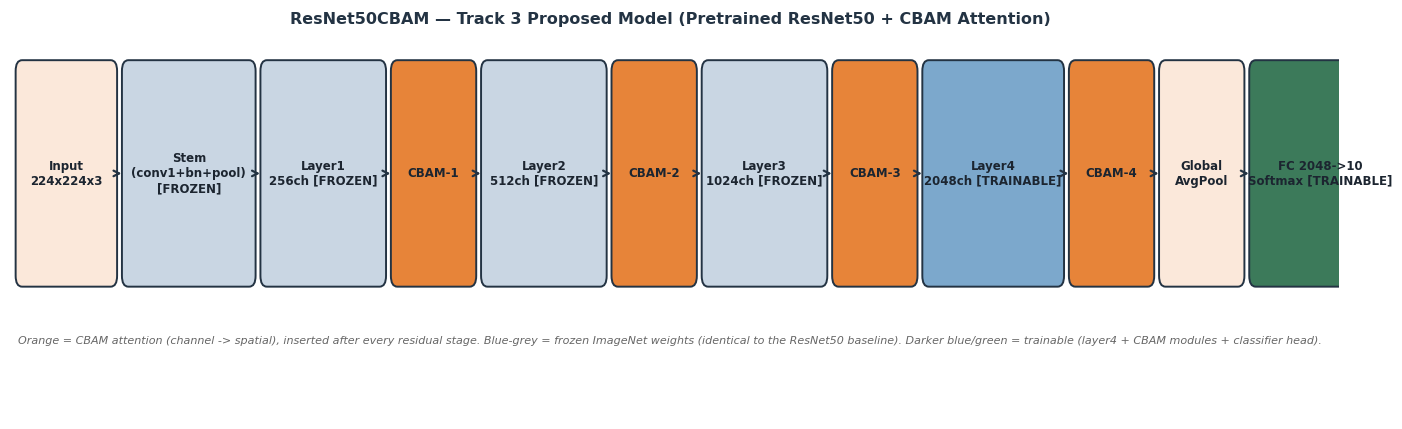

Architecture diagram saved to: /kaggle/working/results/group03_prbd_resnet50_cbam_architecture.png


In [6]:
def draw_architecture_diagram(save_path):
    fig, ax = plt.subplots(figsize=(15, 4.4))
    ax.set_xlim(0, 16.5); ax.set_ylim(0, 3); ax.axis('off')

    def box(x, w, label, color, y=1, h=1.6, fontsize=8.5):
        rect = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.03,rounding_size=0.08",
                               linewidth=1.4, edgecolor='#233343', facecolor=color)
        ax.add_patch(rect)
        ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=fontsize,
                fontweight='bold', color='#1c2530', wrap=True)

    def arrow(x_start, x_end, y=1.8):
        ax.annotate('', xy=(x_end, y), xytext=(x_start, y),
                     arrowprops=dict(arrowstyle='->', lw=1.6, color='#233343'))

    stages = [
        ("Input\n224x224x3", "#FBE8DA", 1.2),
        ("Stem\n(conv1+bn+pool)\n[FROZEN]", "#C9D6E3", 1.6),
        ("Layer1\n256ch [FROZEN]", "#C9D6E3", 1.5),
        ("CBAM-1", "#E78439", 1.0),
        ("Layer2\n512ch [FROZEN]", "#C9D6E3", 1.5),
        ("CBAM-2", "#E78439", 1.0),
        ("Layer3\n1024ch [FROZEN]", "#C9D6E3", 1.5),
        ("CBAM-3", "#E78439", 1.0),
        ("Layer4\n2048ch [TRAINABLE]", "#7CA8CC", 1.7),
        ("CBAM-4", "#E78439", 1.0),
        ("Global\nAvgPool", "#FBE8DA", 1.0),
        ("FC 2048->10\nSoftmax [TRAINABLE]", "#3C7A5A", 1.7),
    ]
    x = 0.1
    positions = []
    for label, color, w in stages:
        positions.append((x, w))
        box(x, w, label, color)
        x += w + 0.12
    for i in range(len(positions) - 1):
        x_end = positions[i][0] + positions[i][1]
        arrow(x_end, positions[i+1][0])

    ax.text(8.2, 2.9, "ResNet50CBAM — Track 3 Proposed Model (Pretrained ResNet50 + CBAM Attention)",
            ha='center', fontsize=11.5, fontweight='bold', color='#233343')
    ax.text(8.2, 0.55,
            "Orange = CBAM attention (channel -> spatial), inserted after every residual stage. "
            "Blue-grey = frozen ImageNet weights (identical to the ResNet50 baseline). "
            "Darker blue/green = trainable (layer4 + CBAM modules + classifier head).",
            ha='center', fontsize=8, color='#666666', style='italic')
    plt.tight_layout()
    plt.savefig(save_path, dpi=160, bbox_inches='tight')
    plt.show()

diagram_path = os.path.join(RESULTS_DIR, "group03_prbd_resnet50_cbam_architecture.png")
draw_architecture_diagram(diagram_path)
print("Architecture diagram saved to:", diagram_path)


## 6. Settings / hyperparameters

| Setting | Value |
|---|---|
| Input size | 224 x 224 x 3 |
| Backbone | ResNet50, ImageNet `IMAGENET1K_V2` pretrained weights |
| Fine-tuning budget | frozen: stem, layer1, layer2 — trainable: layer3, layer4 (v2 update — layer3 unfrozen so backbone co-adapts with CBAM; this is a deliberate, documented deviation from the baseline's frozen layer3)|
| Attention | CBAM after layer1/2/3/4 (channel reduction ratio = 16, spatial kernel = 7x7) — always trainable |
| Classifier head | Dropout(0.3) -> FC(2048->10) |
| Optimizer | Adam, weight_decay = 1e-4 |
| Learning rate | **Differential:** 5e-5 for `layer4` (matches the ResNet50 baseline's fine-tuning LR) — 5e-4 for the 4 CBAM modules + classifier head (these are freshly initialized and benefit from a higher LR to converge within the same epoch budget) |
| LR schedule | ReduceLROnPlateau (factor 0.5, patience 2) on val loss |
| Loss | Cross-entropy |
| Batch size | 32 |
| Max epochs | 50, early stopping patience = 6 (val loss) |
| Augmentation (train only) | H/V flip, +-20 deg rotation, brightness/contrast, hue/saturation, coarse dropout |
| Normalization | ImageNet mean/std (identical to all 4 baselines) |
| Split | identical class-stratified 70/10/20 split loaded from `task2_baselines.ipynb` |

The frozen/unfrozen layer split and the backbone's fine-tuning LR (5e-5) are **copied exactly from
the ResNet50 baseline's recipe** — the two intentional differences are: (1) CBAM attention is added,
and (2) the new CBAM/head parameters get their own, higher learning rate (5e-4) since they start from
random initialization, unlike the pretrained backbone.


## 7. Shared training / evaluation utilities (identical to the baselines notebook, for a fair comparison)

In [7]:
def model_size_mb(model):
    tmp_path = "/tmp/_tmp_model_size.pth"
    torch.save(model.state_dict(), tmp_path)
    size_mb = os.path.getsize(tmp_path) / (1024 ** 2)
    os.remove(tmp_path)
    return size_mb

def build_param_groups(model, backbone_lr=5e-5, attention_lr=5e-4):
    # New, randomly-initialized modules (CBAM + classifier head) often need a
    # higher learning rate than the pretrained backbone being fine-tuned, so
    # they can converge in the same number of epochs instead of moving too
    # slowly at the backbone's small fine-tuning LR.
    backbone_params = list(model.layer4.parameters())
    attention_params = (list(model.cbam1.parameters()) + list(model.cbam2.parameters()) +
                         list(model.cbam3.parameters()) + list(model.cbam4.parameters()) +
                         list(model.classifier.parameters()))
    return [
        {"params": backbone_params, "lr": backbone_lr},
        {"params": attention_params, "lr": attention_lr},
    ]

def train_model(model, model_name, train_loader, val_loader, epochs=EPOCHS, lr=1e-4, patience=PATIENCE, param_groups=None):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    if param_groups is not None:
        optimizer = torch.optim.Adam(param_groups, weight_decay=1e-4)
    else:
        optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    best_val_loss = float('inf'); best_state = None; epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    start_time = time.time()
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward(); optimizer.step()
            running_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
        train_loss = running_loss / total; train_acc = correct / total

        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)
        val_loss = val_running_loss / val_total; val_acc = val_correct / val_total
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc);   history['val_acc'].append(val_acc)
        print(f"[{model_name}] Epoch {epoch+1}/{epochs} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss; best_state = copy.deepcopy(model.state_dict()); epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}."); break

    training_time = time.time() - start_time
    model.load_state_dict(best_state)
    torch.save(best_state, os.path.join(MODELS_DIR, f"{model_name}_best.pth"))
    return model, history, training_time


def evaluate_model(model, model_name, loader, class_names=CLASSES):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    start_time = time.time()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)
            all_labels.extend(labels.numpy()); all_preds.extend(preds); all_probs.extend(probs)
    inference_time = time.time() - start_time
    per_image_ms = (inference_time / len(loader.dataset)) * 1000

    all_labels = np.array(all_labels); all_preds = np.array(all_preds); all_probs = np.array(all_probs)
    acc = accuracy_score(all_labels, all_preds)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0)
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0)
    report = classification_report(all_labels, all_preds, target_names=class_names, zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    y_bin = label_binarize(all_labels, classes=list(range(len(class_names))))
    roc_auc_per_class = {}
    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
        roc_auc_per_class[class_names[i]] = auc(fpr, tpr)
    roc_auc_macro = np.mean(list(roc_auc_per_class.values()))

    metrics = {
        "model": model_name, "accuracy": acc,
        "precision_macro": precision_macro, "recall_macro": recall_macro, "f1_macro": f1_macro,
        "precision_weighted": precision_weighted, "recall_weighted": recall_weighted, "f1_weighted": f1_weighted,
        "roc_auc_macro": roc_auc_macro, "inference_ms_per_image": per_image_ms,
        "n_params": count_params(model), "model_size_mb": model_size_mb(model),
    }
    print(f"\n===== {model_name} — Test set report =====")
    print(report)
    print(f"Accuracy={acc:.4f} | Macro-F1={f1_macro:.4f} | Weighted-F1={f1_weighted:.4f} | Macro ROC-AUC={roc_auc_macro:.4f}")
    return metrics, all_labels, all_preds, all_probs, cm, report


def plot_confusion_matrix(cm, class_names, title):
    fig, ax = plt.subplots(figsize=(9, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    plt.xticks(rotation=75); plt.yticks(rotation=0)
    plt.tight_layout(); plt.show()


def plot_roc_pr_curves(all_labels, all_probs, class_names, title_prefix):
    y_bin = label_binarize(all_labels, classes=list(range(len(class_names))))
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    for i, cname in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        axes[0].plot(fpr, tpr, lw=1, label=f"{cname} (AUC={roc_auc:.2f})")
    axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"{title_prefix} — ROC curves (one-vs-rest)"); axes[0].legend(fontsize=7, loc='lower right')
    for i, cname in enumerate(class_names):
        prec, rec, _ = precision_recall_curve(y_bin[:, i], all_probs[:, i])
        axes[1].plot(rec, prec, lw=1, label=cname)
    axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].set_title(f"{title_prefix} — Precision-Recall curves (one-vs-rest)"); axes[1].legend(fontsize=7, loc='lower left')
    plt.tight_layout(); plt.show()


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(history['train_loss'], label='train'); axes[0].plot(history['val_loss'], label='val')
    axes[0].set_title(f"{title} — Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
    axes[1].plot(history['train_acc'], label='train'); axes[1].plot(history['val_acc'], label='val')
    axes[1].set_title(f"{title} — Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
    plt.tight_layout(); plt.show()


## 8. Train the proposed model (ResNet50 + CBAM)

[resnet50_cbam] Epoch 1/50 | train_loss=2.3005 train_acc=0.1093 | val_loss=2.3013 val_acc=0.1100
[resnet50_cbam] Epoch 2/50 | train_loss=2.1281 train_acc=0.2614 | val_loss=1.8323 val_acc=0.2900
[resnet50_cbam] Epoch 3/50 | train_loss=1.4009 train_acc=0.5371 | val_loss=0.8827 val_acc=0.7500
[resnet50_cbam] Epoch 4/50 | train_loss=0.7343 train_acc=0.7450 | val_loss=0.4934 val_acc=0.8300
[resnet50_cbam] Epoch 5/50 | train_loss=0.5122 train_acc=0.8071 | val_loss=0.3551 val_acc=0.8750
[resnet50_cbam] Epoch 6/50 | train_loss=0.4392 train_acc=0.8436 | val_loss=0.3197 val_acc=0.8900
[resnet50_cbam] Epoch 7/50 | train_loss=0.3735 train_acc=0.8636 | val_loss=0.3248 val_acc=0.8800
[resnet50_cbam] Epoch 8/50 | train_loss=0.3406 train_acc=0.8793 | val_loss=0.3593 val_acc=0.8900
[resnet50_cbam] Epoch 9/50 | train_loss=0.2842 train_acc=0.9029 | val_loss=0.1802 val_acc=0.9500
[resnet50_cbam] Epoch 10/50 | train_loss=0.2843 train_acc=0.8964 | val_loss=0.1793 val_acc=0.9300
[resnet50_cbam] Epoch 11/50 |

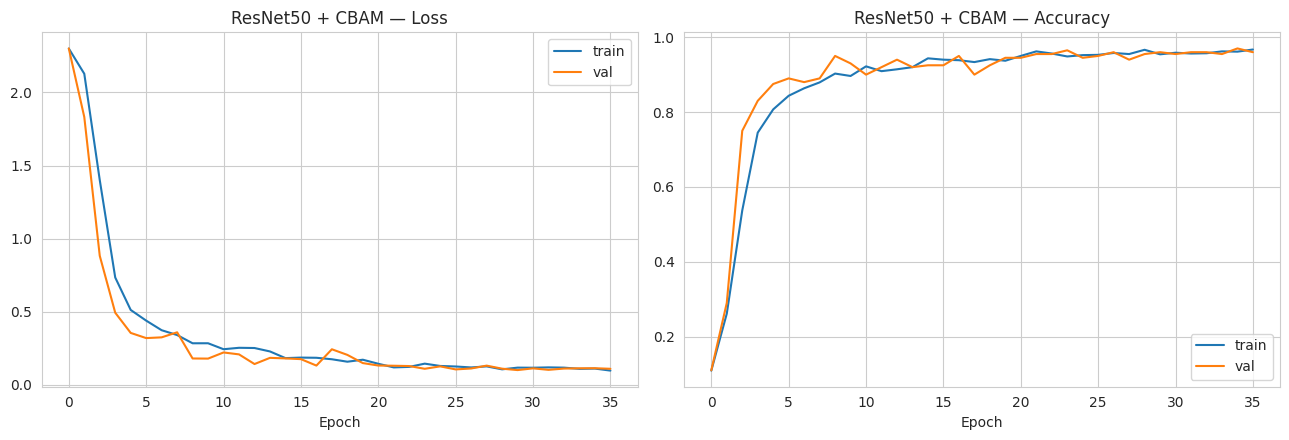

In [8]:
param_groups = build_param_groups(model_proposed, backbone_lr=5e-5, attention_lr=5e-4)
model_proposed, hist_proposed, time_proposed = train_model(
    model_proposed, "resnet50_cbam", train_loader, val_loader, param_groups=param_groups)
plot_history(hist_proposed, "ResNet50 + CBAM")


## 9. Evaluate the proposed model — same full metric set as every baseline


===== ResNet50+CBAM (proposed) — Test set report =====
               precision    recall  f1-score   support

         Aush       1.00      0.97      0.99        40
        BR-28       1.00      0.85      0.92        40
        BR-29       0.93      0.95      0.94        40
        Beroi       0.98      1.00      0.99        40
    Chinigura       1.00      1.00      1.00        40
    Ghee Bhog       0.95      0.88      0.91        40
 Katari Najir       0.90      0.95      0.93        40
Katari Siddho       0.95      1.00      0.98        40
      Miniket       1.00      1.00      1.00        40
       Swarna       0.86      0.95      0.90        40

     accuracy                           0.95       400
    macro avg       0.96      0.95      0.95       400
 weighted avg       0.96      0.95      0.95       400

Accuracy=0.9550 | Macro-F1=0.9548 | Weighted-F1=0.9548 | Macro ROC-AUC=0.9975


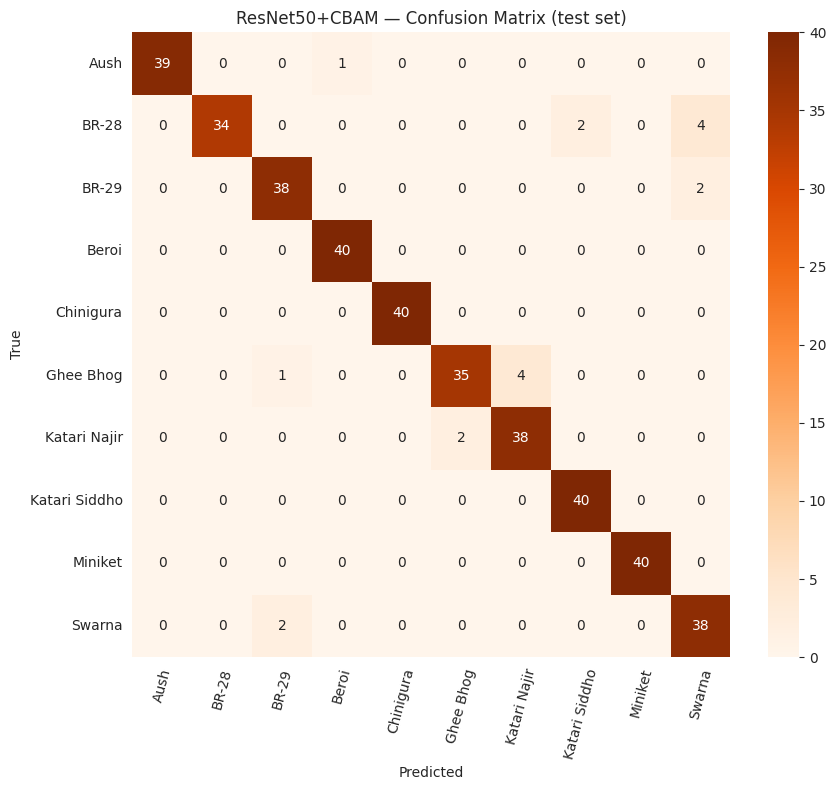

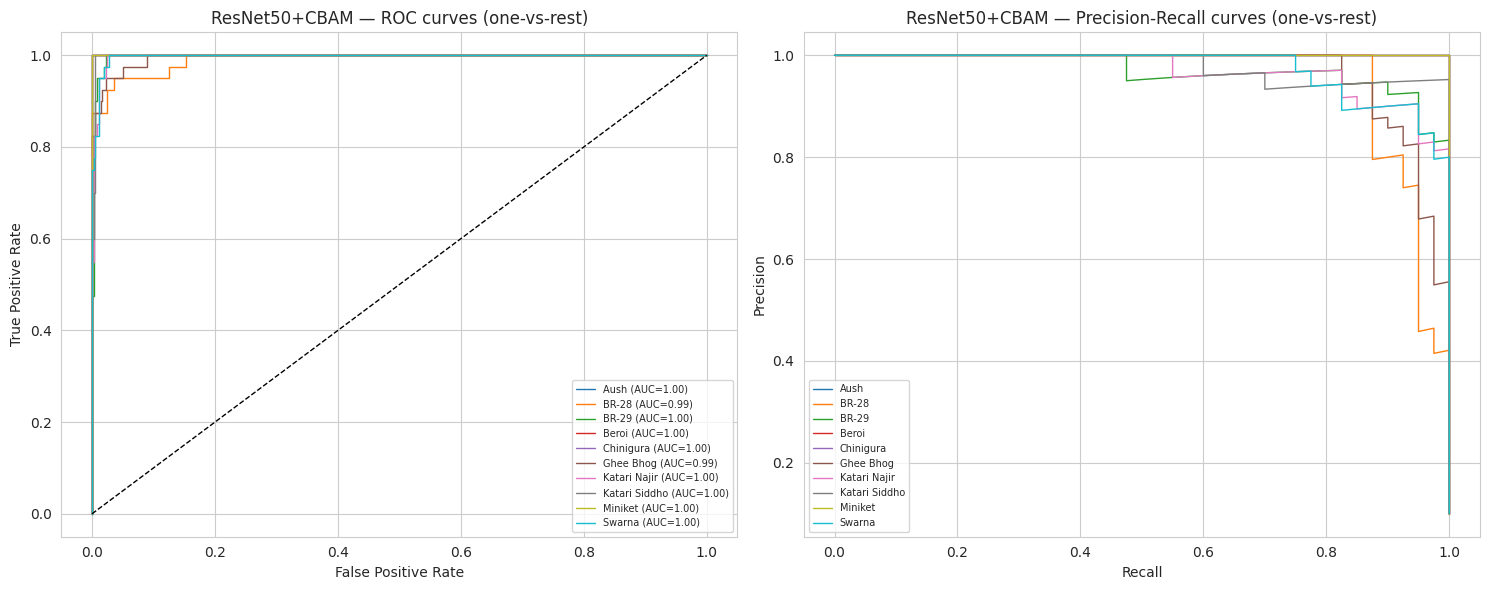

In [9]:
metrics_proposed, y_true_prop, y_pred_prop, y_prob_prop, cm_prop, report_prop = evaluate_model(
    model_proposed, "ResNet50+CBAM (proposed)", test_loader)
metrics_proposed["training_time_sec"] = time_proposed
plot_confusion_matrix(cm_prop, CLASSES, "ResNet50+CBAM — Confusion Matrix (test set)")
plot_roc_pr_curves(y_true_prop, y_prob_prop, CLASSES, "ResNet50+CBAM")


## 10. Quick qualitative check — CBAM spatial-attention maps

A fast visual sanity check (the full Grad-CAM/LIME explainability study is Task 3): we pull the
spatial-attention weights from the last CBAM block (on top of `layer4`) for a few test images and
overlay them, just to confirm the module is producing a non-trivial, localized attention pattern.


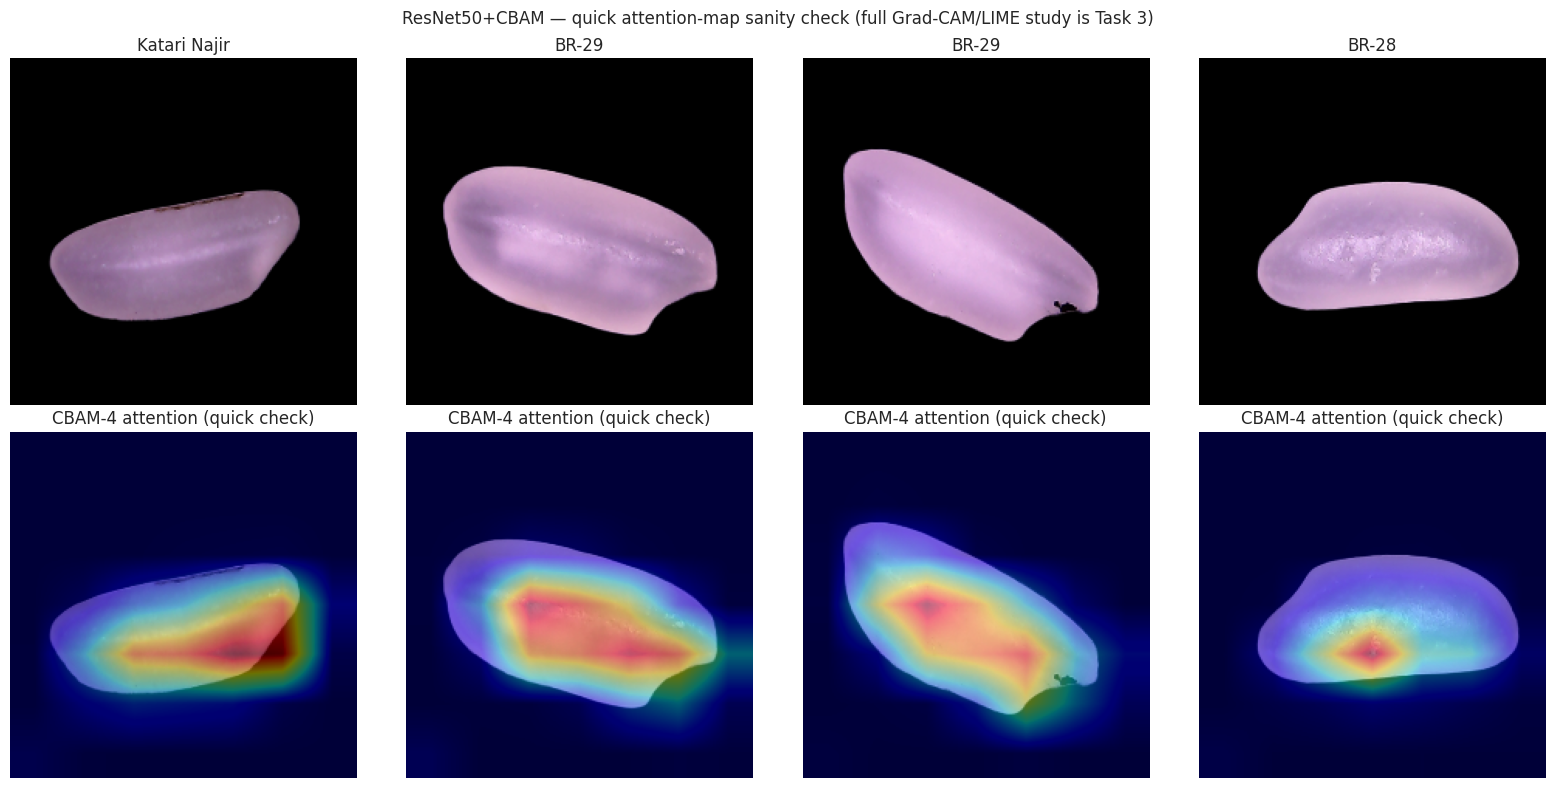

In [10]:
def get_last_cbam_spatial_map(model, img_tensor):
    model.eval()
    with torch.no_grad():
        _, maps = model(img_tensor.unsqueeze(0).to(DEVICE), return_attention_maps=True)
    fmap = maps['cbam4'].squeeze(0).cpu()          # (C, H, W) after CBAM-4
    attn_map = fmap.mean(dim=0).numpy()             # collapse channels for a viewable heatmap
    attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)
    return attn_map

def denorm(img_t):
    img = img_t.permute(1, 2, 0).numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(img, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    img_t, label = test_ds[i]
    attn = get_last_cbam_spatial_map(model_proposed, img_t)
    attn_resized = cv2.resize(attn, (IMG_SIZE, IMG_SIZE))
    axes[0, i].imshow(denorm(img_t)); axes[0, i].set_title(IDX_TO_CLASS[label]); axes[0, i].axis('off')
    axes[1, i].imshow(denorm(img_t)); axes[1, i].imshow(attn_resized, cmap='jet', alpha=0.45)
    axes[1, i].set_title("CBAM-4 attention (quick check)"); axes[1, i].axis('off')
plt.suptitle("ResNet50+CBAM — quick attention-map sanity check (full Grad-CAM/LIME study is Task 3)")
plt.tight_layout(); plt.show()


## 11. Final comparison — best baseline vs. proposed model (does attention help?)

In [11]:
baseline_results_path = resolve_baseline_file("results/group03_prbd_task2_baseline_results.json")
best_baseline_path = resolve_baseline_file("results/group03_prbd_task2_best_baseline.json")

if baseline_results_path is not None:
    with open(baseline_results_path) as f:
        baseline_results = json.load(f)
    comparison_df = pd.DataFrame(baseline_results + [metrics_proposed])
    print("Loaded baseline results from ->", baseline_results_path)
else:
    print("NOTE: task2_baselines.ipynb results not found in /kaggle/working or in",
          BASELINE_INPUT_CANDIDATES, "— make sure that notebook's committed output is attached "
          "via 'Add Input -> Notebook Output Files'. Showing the proposed model's own metrics only for now.")
    comparison_df = pd.DataFrame([metrics_proposed])

col_order = ["model", "accuracy", "precision_macro", "recall_macro", "f1_macro",
             "precision_weighted", "recall_weighted", "f1_weighted", "roc_auc_macro",
             "training_time_sec", "inference_ms_per_image", "n_params", "model_size_mb"]
comparison_df = comparison_df[[c for c in col_order if c in comparison_df.columns]]
comparison_df = comparison_df.sort_values("f1_macro", ascending=False).reset_index(drop=True)
comparison_df.round(4)


Loaded baseline results from -> /kaggle/input/notebooks/rejaul1111/cse475-task2-baselines/results/group03_prbd_task2_baseline_results.json


,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc_macro,training_time_sec,inference_ms_per_image,n_params,model_size_mb
0,ResNet50,0.9625,0.9654,0.9625,0.9625,0.9654,0.9625,0.9625,0.9990,273.6896,6.2503,14985226,90.0600
1,MobileNetV2,0.9625,0.9631,0.9625,0.9622,0.9631,0.9625,0.9622,0.9983,251.3533,6.4339,1538890,8.7680
2,ResNet50+CBAM (proposed),0.9550,0.9569,0.9550,0.9548,0.9569,0.9550,0.9548,0.9975,1115.5515,22.3064,22780306,92.7237
3,EfficientNet-B0,0.9525,0.9540,0.9525,0.9524,0.9540,0.9525,0.9524,0.9985,311.4798,5.8631,3168550,15.6238
4,Simple CNN,0.8900,0.8930,0.8900,0.8898,0.8930,0.8900,0.8898,0.9936,441.2343,8.5681,423562,1.6304


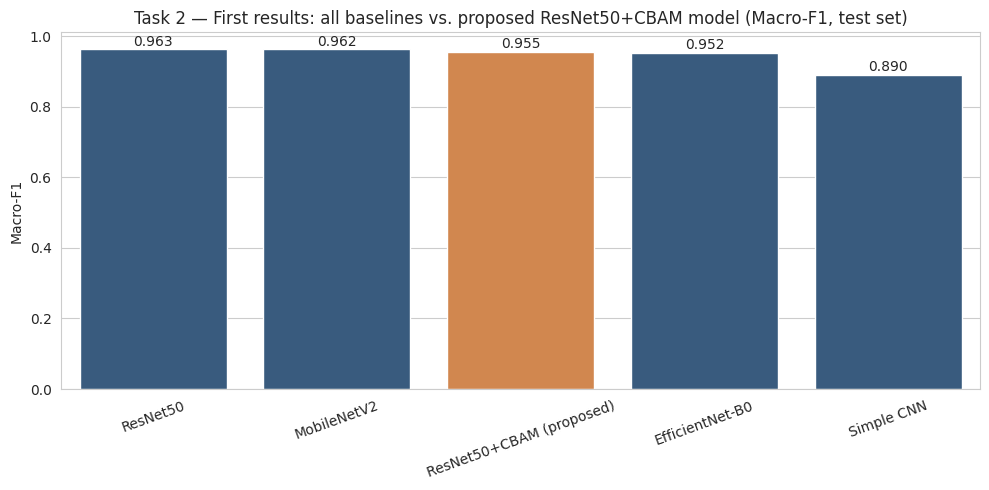

Best baseline: ResNet50 (Macro-F1=0.9625)
Proposed ResNet50+CBAM Macro-F1=0.9548
Delta (proposed - best baseline) = -0.0077


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#E78439' if m == "ResNet50+CBAM (proposed)" else '#2D5B8A' for m in comparison_df['model']]
sns.barplot(data=comparison_df, x="model", y="f1_macro", hue="model", palette=colors, legend=False, ax=ax)
ax.set_title("Task 2 — First results: all baselines vs. proposed ResNet50+CBAM model (Macro-F1, test set)")
ax.set_ylabel("Macro-F1"); ax.set_xlabel("")
for i, v in enumerate(comparison_df['f1_macro']):
    ax.text(i, v + 0.01, f"{v:.3f}", ha='center')
plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

if best_baseline_path is not None:
    with open(best_baseline_path) as f:
        best_info = json.load(f)
    delta = metrics_proposed['f1_macro'] - best_info['best_baseline_f1_macro']
    print(f"Best baseline: {best_info['best_baseline']} (Macro-F1={best_info['best_baseline_f1_macro']:.4f})")
    print(f"Proposed ResNet50+CBAM Macro-F1={metrics_proposed['f1_macro']:.4f}")
    print(f"Delta (proposed - best baseline) = {delta:+.4f}")


Reading: On the same ResNet50 backbone and fine-tuning budget, adding CBAM attention gives Macro-F1 = 0.9548 - 0.0077 lower than the plain ResNet50 baseline (0.9625). So in this first run, attention did not help the strongest backbone; the proposed model ranks 3rd overall, behind ResNet50 and MobileNetV2, just ahead of EfficientNet-B0. This is the opposite of the earlier from-scratch experiment, where CBAM improved a plain Simple CNN by +0.0096 Macro-F1. A plausible explanation is that ResNet50's ImageNet features are already strong and well-suited to this task, leaving CBAM little useful signal to re-weight, while the extra parameters and joint fine-tuning of layer3+layer4 may make optimization harder within the same epoch/LR budget. This negative delta is a legitimate, honestly reported first result - Task 2 does not require beating the baseline yet; Task 3's ablation study (CBAM position, channel-vs-spatial-only, frozen vs. unfrozen layers) is exactly where this will be investigated further.


## 12. Save the proposed model's results (for the Task 2 report and Task 3 reuse)

In [13]:
with open(os.path.join(RESULTS_DIR, "group03_prbd_task2_proposed_model_results.json"), "w") as f:
    json.dump(metrics_proposed, f, indent=2, default=float)

comparison_df.to_csv(os.path.join(RESULTS_DIR, "group03_prbd_task2_full_comparison.csv"), index=False)

print("Saved:")
print(" -", os.path.join(RESULTS_DIR, "group03_prbd_task2_proposed_model_results.json"))
print(" -", os.path.join(RESULTS_DIR, "group03_prbd_task2_full_comparison.csv"))
print(" -", os.path.join(MODELS_DIR, "resnet50_cbam_best.pth"), " (proposed model checkpoint, feeds Task 3)")
print(" -", diagram_path, " (architecture diagram, for the Task 2 report)")


Saved:
 - /kaggle/working/results/group03_prbd_task2_proposed_model_results.json
 - /kaggle/working/results/group03_prbd_task2_full_comparison.csv
 - /kaggle/working/models/resnet50_cbam_best.pth  (proposed model checkpoint, feeds Task 3)
 - /kaggle/working/results/group03_prbd_resnet50_cbam_architecture.png  (architecture diagram, for the Task 2 report)


## Summary — carried into the Task 2 report

- Proposed model: **ImageNet-pretrained ResNet50 + CBAM** (channel + spatial attention) after every
  residual stage — same backbone and fine-tuning budget (frozen up to layer3, trainable layer4) as
  the ResNet50 baseline, isolating attention's effect cleanly.
- Architecture diagram generated and saved (Section 5), showing frozen vs. trainable stages and
  where each CBAM module sits.
- Attention type and backbone choice both justified: CBAM from the Task 1 EDA finding that PRBD
  classes look visually similar; ResNet50 chosen because it was the strongest baseline
  (Macro-F1 0.9625), making it the correct backbone to test "does attention help the best model we
  already have," rather than confounding attention with a weaker, from-scratch backbone.
- Trained and evaluated with the **exact same split, augmentation, and metric set** as the 4
  baselines in `task2_baselines.ipynb` — no leakage, fair comparison.
- Final comparison table + bar chart: best baseline vs. proposed model, answering *"does attention
  help?"* — now on a like-for-like backbone.
- Quick qualitative attention-map check included (full Grad-CAM + LIME explainability is Task 3).
- All results/checkpoints saved to `/kaggle/working/` for direct reuse in `task3_*` notebooks
  (ablation, 5-fold CV + significance test, and full XAI study).
